In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

In [2]:
data = '/pscratch/sd/l/lflores/astrid_hcd_outputs/deltas_0.30'
factor = 0.30

with h5py.File(data, 'r') as f:
    print('Atributes:')
    for k in f.attrs.keys():
        print(f'{k} = {f.attrs[k]}')
    print('----------------') 
    print('Data:')
    print(f.keys())
    delta_hcd = f['deltas/delta_hcd'][:]
    print('delta_hcd shape:', delta_hcd.shape)
    delta_lya = f['deltas/delta_lya'][:]
    print('delta_lya shape:', delta_lya.shape)
    delta_tot = f['deltas/delta_tot'][:]
    print('delta_tot shape:', delta_tot.shape)
    C = f['C'][()]  # Scalar data
    print('C:', C)

Atributes:
Smoothing factor = 0.3
logNHI_max = 21.3
logNHI_min = 0
----------------
Data:
<KeysViewHDF5 ['C', 'deltas', 'mean_fluxes']>
delta_hcd shape: (238191, 2500)
delta_lya shape: (238191, 2500)
delta_tot shape: (238191, 2500)
C: 0.00561013489337836


In [3]:
print('----- Useful information -----')
Lbox = 250  # Mpc/h
print('box size:', Lbox, 'Mpc/h')

# Number of skewers per side
Nsk = 500  # colden.on_shape[0] gives the size of the axis
print(Nsk,'skewers per side')

# Number of pixels per skewer
Np = 2500 # colden.on_shape[1] gives the size of the columns
print(Np, 'pixels per skewer')

# Pixel width 
Pw = Lbox/Np  # Mpc/h 
print(Pw, 'Mpc/h pixel width')
# We are dividing the total box width in comoving units by the number of pixels in each skewer

# Minimum separation between skewers
Ssk = Lbox/Nsk  # Mpc/h 
print(Ssk, 'Mpc/h skewer separation')
# We are dividing the total box width in comoving units by the number of skewers per side

----- Useful information -----
box size: 250 Mpc/h
500 skewers per side
2500 pixels per skewer
0.1 Mpc/h pixel width
0.5 Mpc/h skewer separation


In [4]:
# ASTRID cosmology values
hubble, z = 0.6774, 2.5

# Calculating P1D 

We are going to split the box into others

In [5]:
Nbox = 25  # Number of miniboxes 
nskw = delta_hcd.shape[0]//Nbox

delta_hcd_mb = np.zeros(shape=(Nbox, nskw, Np))
delta_lya_mb = np.zeros(shape=(Nbox, nskw, Np))
delta_tot_mb = np.zeros(shape=(Nbox, nskw, Np))

for i in range(Nbox):
    skw_init, skw_end= 0+(i*nskw),(i+1)*nskw
    delta_hcd_mb[i] = delta_hcd[skw_init:skw_end][:]
    delta_lya_mb[i] = delta_lya[skw_init:skw_end][:]
    delta_tot_mb[i] = delta_tot[skw_init:skw_end][:]

In [6]:
del delta_tot, delta_hcd, delta_lya

In [7]:
fft_tot = np.fft.rfft(delta_tot_mb)
fft_lya = np.fft.rfft(delta_lya_mb)
fft_hcd = np.fft.rfft(delta_hcd_mb)
fft_lyahcd = np.fft.rfft(delta_hcd_mb*delta_lya_mb)

k_los = 2*np.pi*np.fft.rfftfreq(Np, d=Pw*hubble)

In [8]:
del delta_tot_mb, delta_lya_mb, delta_hcd_mb

## Total

In [9]:
p1ds_tot = fft_tot*fft_tot.conjugate()*(Lbox*hubble/Np**2)
del fft_tot

In [10]:
P1d_boxes = np.mean(p1ds_tot, axis=1)
P1d_tot = np.mean(P1d_boxes, axis=0)
P1d_std_tot = np.std(P1d_boxes, axis=0, ddof=1)/np.sqrt(Nbox)
del p1ds_tot

In [24]:
output = '/pscratch/sd/l/lflores/astrid_hcd_outputs/p1d_%.2f' %factor

with h5py.File(output, 'w') as f:
    f.create_dataset('k', data=k_los)
    
    grp1 = f.create_group('P1Ds')
    grp1.create_dataset('P1D_tot', data=P1d_tot)

    grp1 = f.create_group('P1Ds_std')
    grp1.create_dataset('P1D_std_tot', data=P1d_std_tot)

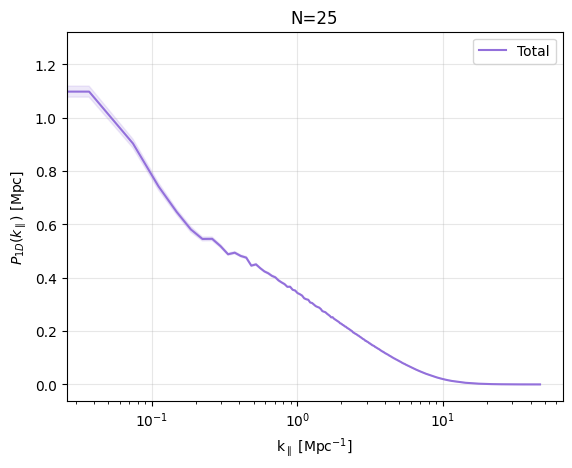

In [14]:
plt.plot(k_los, P1d_tot/hubble, color='mediumpurple', label='Total')
plt.fill_between(k_los, (P1d_tot/hubble-P1d_std_tot), (P1d_tot/hubble+P1d_std_tot), color='mediumpurple', alpha=0.15)
plt.xscale('log')
plt.legend()
plt.grid(alpha=0.3)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'$P_{1D}(k_\parallel)$ [Mpc]')
plt.title('N=%.0f' %Nbox);

## Lya

In [15]:
p1ds_lya = fft_lya*fft_lya.conjugate()*(Lbox*hubble/Np**2)

In [16]:
P1d_boxes = np.mean(p1ds_lya, axis=1)
P1d_lya = np.mean(P1d_boxes, axis=0)
P1d_std_lya = np.std(P1d_boxes, axis=0, ddof=1)/np.sqrt(Nbox)
del p1ds_lya

In [25]:
output = '/pscratch/sd/l/lflores/astrid_hcd_outputs/p1d_%.2f' %factor

with h5py.File(output, 'a') as f:
  
    grp1 = f['P1Ds']
    if 'P1D_lya' in grp1:
        grp1['P1D_lya'][...] = P1d_lya
    else:
        grp1.create_dataset('P1D_lya', data=P1d_lya)

    grp2 = f['P1Ds_std']
    if 'P1D_std_lya' in grp2:
        grp2['P1D_std_lya'][...] = P1d_std_lya
    else:
        grp2.create_dataset('P1D_std_lya', data=P1d_std_lya)

## HCDs

In [26]:
p1ds_hcd = fft_hcd*fft_hcd.conjugate()*(Lbox*hubble/Np**2)

In [27]:
P1d_boxes = np.mean(p1ds_hcd, axis=1)
P1d_hcd = np.mean(P1d_boxes, axis=0)
P1d_std_hcd = np.std(P1d_boxes, axis=0, ddof=1)/np.sqrt(Nbox)
del p1ds_hcd

In [28]:
output = '/pscratch/sd/l/lflores/astrid_hcd_outputs/p1d_%.2f' %factor

with h5py.File(output, 'a') as f:
  
    grp1 = f['P1Ds']
    if 'P1D_hcd' in grp1:
        grp1['P1D_hcd'][...] = P1d_hcd
    else:
        grp1.create_dataset('P1D_hcd', data=P1d_hcd)

    grp2 = f['P1Ds_std']
    if 'P1D_std_hcd' in grp2:
        grp2['P1D_std_hcd'][...] = P1d_std_hcd
    else:
        grp2.create_dataset('P1D_std_hcd', data=P1d_std_hcd)

## LyaxHCD

In [29]:
p1ds_lyahcd = fft_lya*fft_hcd.conjugate()*Lbox*hubble/(Np**2)

In [30]:
P1d_boxes = np.mean(p1ds_lyahcd, axis=1)
P1d_lyahcd = np.mean(P1d_boxes, axis=0)
P1d_std_lyahcd = np.std(P1d_boxes, axis=0, ddof=1)/np.sqrt(Nbox)
del p1ds_lyahcd

In [31]:
output = '/pscratch/sd/l/lflores/astrid_hcd_outputs/p1d_%.2f' %factor

with h5py.File(output, 'a') as f:
  
    grp1 = f['P1Ds']
    if 'P1D_lyahcd' in grp1:
        grp1['P1D_lyahcd'][...] = P1d_lyahcd
    else:
        grp1.create_dataset('P1D_lyahcd', data=P1d_lyahcd)
        
    grp2 = f['P1Ds_std']
    if 'P1D_std_lyahcd' in grp2:
        grp2['P1D_std_lyahcd'][...] = P1d_std_lyahcd
    else:
        grp2.create_dataset('P1D_std_lyahcd', data=P1d_std_lyahcd)

## 3Lya

In [32]:
p1ds_3lya = fft_lyahcd*fft_lya.conjugate()*Lbox*hubble/(Np**2)

In [33]:
P1d_boxes = np.mean(p1ds_3lya, axis=1)
P1d_3lya = np.mean(P1d_boxes, axis=0)
P1d_std_3lya = np.std(P1d_boxes, axis=0, ddof=1)/np.sqrt(Nbox)
del p1ds_3lya

In [34]:
output = '/pscratch/sd/l/lflores/astrid_hcd_outputs/p1d_%.2f' %factor

with h5py.File(output, 'a') as f:
  
    grp1 = f['P1Ds']
    if 'P1D_3lya' in grp1:
        grp1['P1D_3lya'][...] = P1d_3lya
    else:
        grp1.create_dataset('P1D_3lya', data=P1d_3lya)

    grp2 = f['P1Ds_std']
    if 'P1D_std_3lya' in grp2:
        grp2['P1D_std_3lya'][...] = P1d_std_3lya
    else:
        grp2.create_dataset('P1D_std_3lya', data=P1d_std_3lya)

## 3HCD

In [35]:
p1ds_3hcd = fft_lyahcd*fft_hcd.conjugate()*Lbox*hubble/(Np**2)

In [36]:
P1d_boxes = np.mean(p1ds_3hcd, axis=1)
P1d_3hcd = np.mean(P1d_boxes, axis=0)
P1d_std_3hcd = np.std(P1d_boxes, axis=0, ddof=1)/np.sqrt(Nbox)
del p1ds_3hcd

In [37]:
output = '/pscratch/sd/l/lflores/astrid_hcd_outputs/p1d_%.2f' %factor

with h5py.File(output, 'a') as f:
  
    grp1 = f['P1Ds']
    if 'P1D_3hcd' in grp1:
        grp1['P1D_3hcd'][...] = P1d_3hcd
    else:
        grp1.create_dataset('P1D_3hcd', data=P1d_3hcd)

    grp2 = f['P1Ds_std']
    if 'P1D_std_3hcd' in grp2:
        grp2['P1D_std_3hcd'][...] = P1d_std_3hcd
    else:
        grp2.create_dataset('P1D_std_3hcd', data=P1d_std_3hcd)

## 4

In [38]:
p1ds_4 = fft_lyahcd*fft_lyahcd.conjugate()*Lbox*hubble/(Np**2) - C**2

In [39]:
P1d_boxes = np.mean(p1ds_4, axis=1)
P1d_4 = np.mean(P1d_boxes, axis=0)
P1d_std_4 = np.std(P1d_boxes, axis=0, ddof=1)/np.sqrt(Nbox)
del p1ds_4

In [40]:
output = '/pscratch/sd/l/lflores/astrid_hcd_outputs/p1d_%.2f' %factor

with h5py.File(output, 'a') as f:
  
    grp1 = f['P1Ds']
    if 'P1D_4' in grp1:
        grp1['P1D_4'][...] = P1d_4
    else:
        grp1.create_dataset('P1D_4', data=P1d_4)

    grp2 = f['P1Ds_std']
    if 'P1D_std_4' in grp2:
        grp2['P1D_std_4'][...] = P1d_std_4
    else:
        grp2.create_dataset('P1D_std_4', data=P1d_std_4)

# Figures

In [42]:
data = '/pscratch/sd/l/lflores/astrid_hcd_outputs/p1d_0.30'

with h5py.File(data, 'r') as f:
    print('Atributes:')
    for m in f.attrs.keys():
        print(f'{m} = {f.attrs[m]}')
    print('----------------') 
    print('Data:')
    print(f.keys())
    k_los = f['k'][:]
    print('k_los shape:', k_los.shape)
    p1d_tot, p1d_std_tot = f['P1Ds/P1D_tot'][:], f['P1Ds_std/P1D_std_tot'][:]
    print('P1d_tot shape:', p1d_tot.shape)
    p1d_lya, p1d_std_lya = f['P1Ds/P1D_lya'][:], f['P1Ds_std/P1D_std_lya'][:]
    print('P1d_lya shape:', p1d_lya.shape)
    p1d_hcd, p1d_std_hcd = f['P1Ds/P1D_hcd'][:], f['P1Ds_std/P1D_std_hcd'][:]
    print('P1d_hcd shape:', p1d_hcd.shape)
    p1d_lyahcd, p1d_std_lyahcd = f['P1Ds/P1D_lyahcd'][:], f['P1Ds_std/P1D_std_lyahcd'][:]
    print('P1d_lyahcd shape:', p1d_lyahcd.shape)
    p1d_3lya, p1d_std_3lya = f['P1Ds/P1D_3lya'][:], f['P1Ds_std/P1D_std_3lya'][:]
    print('P1d_3lya shape:', p1d_3lya.shape)
    p1d_3hcd, p1d_std_3hcd = f['P1Ds/P1D_3hcd'][:], f['P1Ds_std/P1D_std_3hcd'][:]
    print('P1d_3hcd shape:', p1d_3hcd.shape)
    p1d_4, p1d_std_4 = f['P1Ds/P1D_4'][:], f['P1Ds_std/P1D_std_4'][:]
    print('P1d_4 shape:', p1d_4.shape)

Atributes:
----------------
Data:
<KeysViewHDF5 ['P1Ds', 'P1Ds_std', 'k']>
k_los shape: (1251,)
P1d_tot shape: (1251,)
P1d_lya shape: (1251,)
P1d_hcd shape: (1251,)
P1d_lyahcd shape: (1251,)
P1d_3lya shape: (1251,)
P1d_3hcd shape: (1251,)
P1d_4 shape: (1251,)


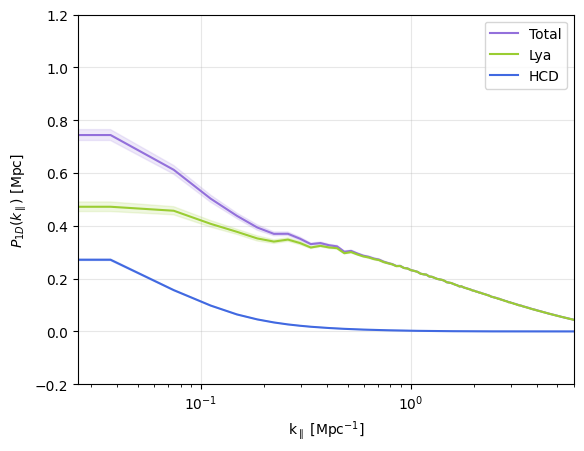

In [46]:
plt.plot(k_los, p1d_tot, color='mediumpurple', label='Total')
plt.fill_between(k_los, (p1d_tot-p1d_std_tot), (p1d_tot+p1d_std_tot), color='mediumpurple', alpha=0.15)
plt.plot(k_los, p1d_lya, color='yellowgreen', label='Lya')
plt.fill_between(k_los, (p1d_lya-p1d_std_lya), (p1d_lya+p1d_std_lya), color='yellowgreen', alpha=0.15)
plt.plot(k_los, p1d_hcd, color='royalblue', label='HCD')
plt.fill_between(k_los, (p1d_hcd-p1d_std_hcd), (p1d_hcd+p1d_std_hcd), color='royalblue', alpha=0.15)
plt.xscale('log')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(right=6)
plt.ylim(-0.2, 1.2)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'$P_{1D}(k_\parallel)$ [Mpc]');

/tmp/ipykernel_683934/1812129646.py:1: RuntimeWarning: divide by zero encountered in log10
  plt.plot(np.log10(k_los), p1d_hcd/p1d_lya, label='ASTRID')


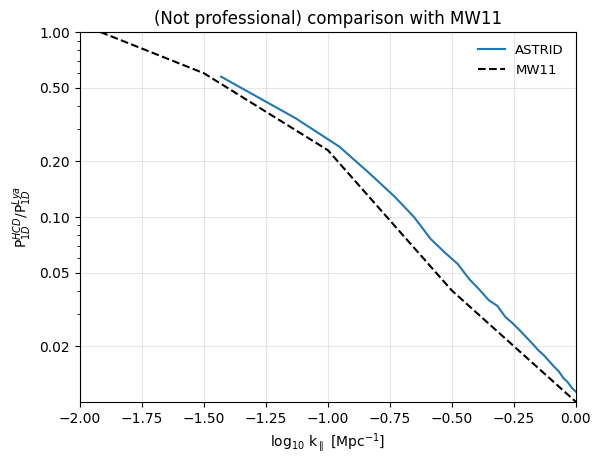

In [47]:
plt.plot(np.log10(k_los), p1d_hcd/p1d_lya, label='ASTRID')
plt.yscale('log')
yticks = np.array([0.02, 0.05, 0.10, 0.20, 0.50, 1.00, 2.00])
plt.plot([-2, -1.5, -1, -0.5, 0], [0.11+1, 0.1+0.5, 0.03+0.2, 0.04, 0.01], linestyle='--', color='k', label='MW11')
plt.yticks(yticks, [f"{y:.2f}" for y in yticks])
plt.grid(alpha=0.3)
plt.legend(fontsize=9.5, frameon=False)
plt.xlabel(r'log$_{10}$ k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'P$_{1D}^{HCD}$/P$_{1D}^{Lya}$')
plt.xlim(-2, 0)
plt.ylim(0.01, 1)
plt.title('(Not professional) comparison with MW11');

In [48]:
p1d_34 = 2*p1d_3lya + 2*p1d_3hcd + p1d_4
p1d_model = (p1d_lya + p1d_hcd + (2*p1d_lyahcd) + p1d_34)/((1+C)**2)

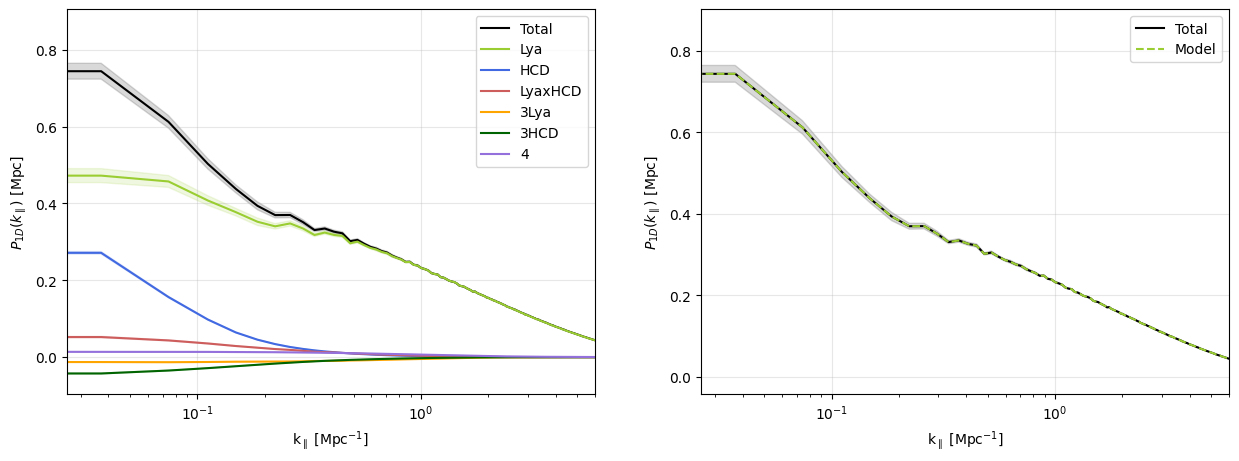

In [52]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(k_los, p1d_tot, color='k', label='Total')
plt.fill_between(k_los, (p1d_tot-p1d_std_tot), (p1d_tot+p1d_std_tot), color='k', alpha=0.15)
plt.plot(k_los, p1d_lya, color='yellowgreen', label='Lya')
plt.fill_between(k_los, (p1d_lya-p1d_std_lya), (p1d_lya+p1d_std_lya), color='yellowgreen', alpha=0.15)
plt.plot(k_los, p1d_hcd, color='royalblue', label='HCD')
plt.fill_between(k_los, (p1d_hcd-p1d_std_hcd), (p1d_hcd+p1d_std_hcd), color='royalblue', alpha=0.15)
plt.plot(k_los, p1d_lyahcd, color='indianred', label='LyaxHCD')
plt.fill_between(k_los, (p1d_lyahcd-p1d_std_lyahcd), (p1d_lyahcd+p1d_std_lyahcd), color='indianred', alpha=0.15)
plt.plot(k_los, p1d_3lya, color='orange', label='3Lya')
plt.fill_between(k_los, (p1d_3lya-p1d_std_3lya), (p1d_3lya+p1d_std_3lya), color='orange', alpha=0.15)
plt.plot(k_los, p1d_3hcd, color='darkgreen', label='3HCD')
plt.fill_between(k_los, (p1d_3hcd-p1d_std_3hcd), (p1d_3hcd+p1d_std_3hcd), color='darkgreen', alpha=0.15)
plt.plot(k_los, p1d_4, color='mediumpurple', label='4')
plt.fill_between(k_los, (p1d_4-p1d_std_4), (p1d_4+p1d_std_4), color='mediumpurple', alpha=0.15)

plt.xscale('log')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(right=6)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'$P_{1D}(k_\parallel)$ [Mpc]')


plt.subplot(1, 2, 2)
plt.plot(k_los, p1d_tot, color='k', label='Total')
plt.fill_between(k_los, (p1d_tot-p1d_std_tot), (p1d_tot+p1d_std_tot), color='k', alpha=0.15)
plt.plot(k_los, p1d_model, linestyle='--', color='yellowgreen', label='Model')

plt.xscale('log')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(right=6)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'$P_{1D}(k_\parallel)$ [Mpc]');

In [53]:
p1d_aprox, p1d_maxstd_aprox = p1d_lya+p1d_hcd+(2*p1d_lyahcd)/((1+C)**2), p1d_std_lya+p1d_std_hcd+(2*p1d_std_lyahcd)/((1+C)**2)

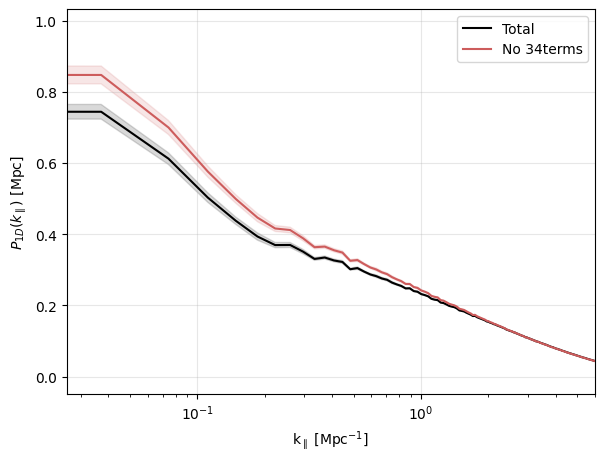

In [54]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(k_los, p1d_tot, color='k', label='Total')
plt.fill_between(k_los, (p1d_tot-p1d_std_tot), (p1d_tot+p1d_std_tot), color='k', alpha=0.15)
plt.plot(k_los, p1d_aprox, color='indianred', label='No 34terms')
plt.fill_between(k_los, (p1d_aprox-p1d_maxstd_aprox), (p1d_aprox+p1d_maxstd_aprox), color='indianred', alpha=0.15)
plt.xscale('log')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(right=6)
plt.xlabel(r'k$_\parallel$ [Mpc$^{-1}$]')
plt.ylabel(r'$P_{1D}(k_\parallel)$ [Mpc]');